In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, SGDRegressor, LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from IPython.display import display

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

sns.set(style="whitegrid", font_scale=1.1)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [ ]:
wdi_file = "WDICSV.csv"
country_file = "WDICountry.csv"

df_wide = pd.read_csv(wdi_file)
df_country = pd.read_csv(country_file)

print("WDICSV (wide) shape:", df_wide.shape)
print(df_wide.head())

print("\nWDICountry columns:", df_country.columns.tolist())
df_country.head()

WDICSV (wide) shape: (403256, 69)
                  Country Name Country Code                                     Indicator Name     Indicator Code  1960  1961  1962  1963  \
0  Africa Eastern and Southern          AFE  Access to clean fuels and technologies for coo...     EG.CFT.ACCS.ZS   NaN   NaN   NaN   NaN   
1  Africa Eastern and Southern          AFE  Access to clean fuels and technologies for coo...  EG.CFT.ACCS.RU.ZS   NaN   NaN   NaN   NaN   
2  Africa Eastern and Southern          AFE  Access to clean fuels and technologies for coo...  EG.CFT.ACCS.UR.ZS   NaN   NaN   NaN   NaN   
3  Africa Eastern and Southern          AFE            Access to electricity (% of population)     EG.ELC.ACCS.ZS   NaN   NaN   NaN   NaN   
4  Africa Eastern and Southern          AFE  Access to electricity, rural (% of rural popul...  EG.ELC.ACCS.RU.ZS   NaN   NaN   NaN   NaN   

   1964  1965  1966  1967  1968  1969  1970  1971  1972  1973  1974  1975  1976  1977  1978  1979  1980  1981  1982  19

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,National accounts base year,National accounts reference year,SNA price valuation,Lending category,Other groups,System of National Accounts,Alternative conversion factor,PPP survey year,Balance of Payments Manual in use,External debt Reporting status,System of trade,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,NaN,Latin America & Caribbean,High income,AW,2013,NaN,Value added at basic prices (VAB),NaN,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,BPM6,NaN,General trade system,NaN,Enhanced General Data Dissemination System (e-...,2020 (expected),NaN,NaN,Yes,NaN,NaN,2018.0,NaN
1,AFE,Africa Eastern and Southern,Africa Eastern and Southern,Africa Eastern and Southern,ZH,NaN,"26 countries, stretching from the Red Sea in t...",NaN,NaN,ZH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,The reporting period for national accounts dat...,Middle East & North Africa,Low income,AF,2016,NaN,Value added at basic prices (VAB),IDA,HIPC,Country uses the 2008 System of National Accou...,NaN,NaN,BPM6,Estimate,General trade system,Consolidated central government,Enhanced General Data Dissemination System (e-...,1979,Multiple Indicator Cluster Survey 2022-2023,"Integrated household survey (IHS), 2016/17",NaN,NaN,NaN,2018.0,NaN
3,AFW,Africa Western and Central,Africa Western and Central,Africa Western and Central,ZI,NaN,"22 countries, stretching from the westernmost ...",NaN,NaN,ZI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,The World Bank systematically assesses the app...,Sub-Saharan Africa,Lower middle income,AO,2002,NaN,Value added at basic prices (VAB),IBRD,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,BPM6,Actual,General trade system,Budgetary central government,Enhanced General Data Dissemination System (e-...,2014,Demographic and Health Survey 2015/16,"Integrated household survey (IHS), 2008/09",NaN,NaN,NaN,2018.0,NaN


In [ ]:
# Convert Wide WDI to Long Format (Year, Value)

year_cols = [col for col in df_wide.columns if col.isdigit()]

df_long = df_wide.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
df_long = df_long.dropna(subset=["Value"]).copy()

print("Long format shape:", df_long.shape)
df_long.head()

Long format shape: (8961187, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
50,Africa Eastern and Southern,AFE,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,135.792572
56,Africa Eastern and Southern,AFE,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,88.967790
57,Africa Eastern and Southern,AFE,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,5.631545
58,Africa Eastern and Southern,AFE,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,82.970097
84,Africa Eastern and Southern,AFE,Aquaculture production (metric tons),ER.FSH.AQUA.MT,1960,380.000000


In [ ]:
# Filter to just countries (exclude aggregates like regions)

if "Region" in df_country.columns:
    real_countries = df_country[df_country["Region"].notna()]["Country Code"].unique()
    df_long = df_long[df_long["Country Code"].isin(real_countries)].copy()
    print("After filtering to real countries:", df_long.shape)
else:
    print("Warning: 'Region' column not found; skipping aggregate filter.")


df_long.head()

After filtering to real countries: (7430249, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
74334,Afghanistan,AFG,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,140.598000
74340,Afghanistan,AFG,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,81.061389
74341,Afghanistan,AFG,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,5.112019
74342,Afghanistan,AFG,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,75.949370
74368,Afghanistan,AFG,Aquaculture production (metric tons),ER.FSH.AQUA.MT,1960,0.000000


In [ ]:
# Filter to year 2000 and after
df_long = df_long[df_long["Year"] >= 2000].copy()
print("After Year >= 2000:", df_long.shape)

After Year >= 2000: (4353126, 6)


In [ ]:
# Select Indicators

# Map WDI codes to readable names
indicator_map = {
    "SP.DYN.LE00.IN":       "Life Expectancy (Years)",
    "NY.GDP.PCAP.CD":       "GDP per Capita (US$)",
    "SP.DYN.TFRT.IN":       "Fertility Rate (Births per Woman)",
    "SP.POP.TOTL":          "Population (Total)",
    "SP.URB.TOTL.IN.ZS":    "Urban Population (%)",
    "EN.GHG.CO2.PC.CE.AR5": "CO2 Emissions per Capita",
    "SH.XPD.CHEX.GD.ZS":    "Health Expenditure (% GDP)",
    "SH.MED.PHYS.ZS":       "Physicians per 1000",
    "SH.H2O.BASW.ZS":       "Basic Drinking Water Access (%)",
    "SE.SEC.CMPT.LO.ZS":    "Lower Secondary Completion (%)"

}
wanted_codes = list(indicator_map.keys())
df_sel = df_long[df_long["Indicator Code"].isin(wanted_codes)].copy()
print("Selected indicators shape:", df_sel.shape)


Selected indicators shape: (46065, 6)


In [ ]:
# Pivot to Country-Year Wide Table with Readable Names

df_pivot = df_sel.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Indicator Code",
    values="Value"
).reset_index()

df_pivot = df_pivot.rename(columns=indicator_map)

print("After pivot:", df_pivot.shape)
df_pivot.head()


After pivot: (5425, 13)


Indicator Code,Country Name,Country Code,Year,CO2 Emissions per Capita,GDP per Capita (US$),Lower Secondary Completion (%),Basic Drinking Water Access (%),Physicians per 1000,Health Expenditure (% GDP),Life Expectancy (Years),Fertility Rate (Births per Woman),Population (Total),Urban Population (%)
0,Afghanistan,AFG,2000,0.050476,174.930991,NaN,27.441856,NaN,NaN,55.005,7.566,20130327.0,22.078
1,Afghanistan,AFG,2001,0.046573,138.706822,NaN,27.473580,0.208,NaN,55.511,7.453,20284307.0,22.169
2,Afghanistan,AFG,2002,0.044078,178.954088,NaN,29.674863,NaN,9.443391,56.225,7.320,21378117.0,22.261
3,Afghanistan,AFG,2003,0.044341,198.871116,NaN,31.875589,NaN,8.941258,57.171,7.174,22733049.0,22.353
4,Afghanistan,AFG,2004,0.037898,221.763654,NaN,34.094431,NaN,9.808474,57.810,7.018,23560654.0,22.500


In [ ]:
target_col = "Life Expectancy (Years)"

# Keep only rows with target
df_model = df_pivot.dropna(subset=[target_col]).copy()
print("Rows with target:", df_model.shape[0])

# Create log features
if "GDP per Capita (US$)" in df_model.columns:
    df_model["log GDP per Capita"] = np.log1p(df_model["GDP per Capita (US$)"])

if "Population (Total)" in df_model.columns:
    df_model["log Population"] = np.log1p(df_model["Population (Total)"])

if "CO2 Emissions per Capita" in df_model.columns:
    co2 = df_model["CO2 Emissions per Capita"].clip(lower=0)
    df_model["log CO2 per Capita"] = np.log1p(co2)

print("df_model columns:")
print(df_model.columns.tolist())

Rows with target: 5208
df_model columns:
['Country Name', 'Country Code', 'Year', 'CO2 Emissions per Capita', 'GDP per Capita (US$)', 'Lower Secondary Completion (%)', 'Basic Drinking Water Access (%)', 'Physicians per 1000', 'Health Expenditure (% GDP)', 'Life Expectancy (Years)', 'Fertility Rate (Births per Woman)', 'Population (Total)', 'Urban Population (%)', 'log GDP per Capita', 'log Population', 'log CO2 per Capita']


In [ ]:
# Final Feature List

feature_candidates = [
    "log GDP per Capita",
    "Fertility Rate (Births per Woman)",
    "Urban Population (%)",
    "log Population",
    "log CO2 per Capita",
    "Health Expenditure (% GDP)",
    "Physicians per 1000",
    "Basic Drinking Water Access (%)",
    "Lower Secondary Completion (%)"
]

# Drop rows with missing features
df_model = df_model.dropna(subset=feature_candidates).copy()
print("Rows after dropping NA on features:", df_model.shape[0])


Rows after dropping NA on features: 1637


In [ ]:
print(df_model[["Life Expectancy (Years)"] + feature_candidates].describe().T)

                                    count       mean        std        min        25%        50%        75%         max
Indicator Code                                                                                                         
Life Expectancy (Years)            1637.0  72.371452   7.909411  14.665000  67.905000  73.751000  78.446341   83.904878
log GDP per Capita                 1637.0   8.694091   1.515584   4.837828   7.565530   8.717730   9.916546   11.725450
Fertility Rate (Births per Woman)  1637.0   2.519719   1.325950   0.808000   1.583000   2.030000   2.911000    7.797000
Urban Population (%)               1637.0  59.617367  21.776003   9.139000  43.608000  61.542000  76.413000  100.000000
log Population                     1637.0  15.853344   1.721158   9.249561  14.866446  15.956999  16.948731   21.061606
log CO2 per Capita                 1637.0   1.486917   0.872741   0.000000   0.737431   1.568239   2.142757    4.284425
Health Expenditure (% GDP)         1637.

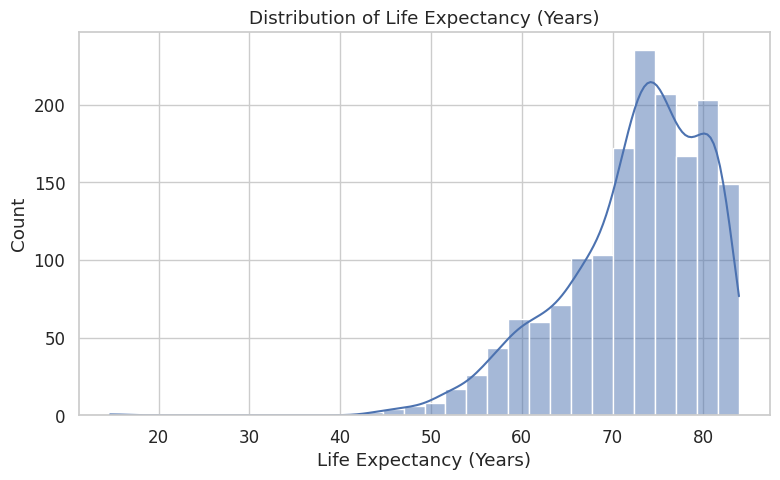

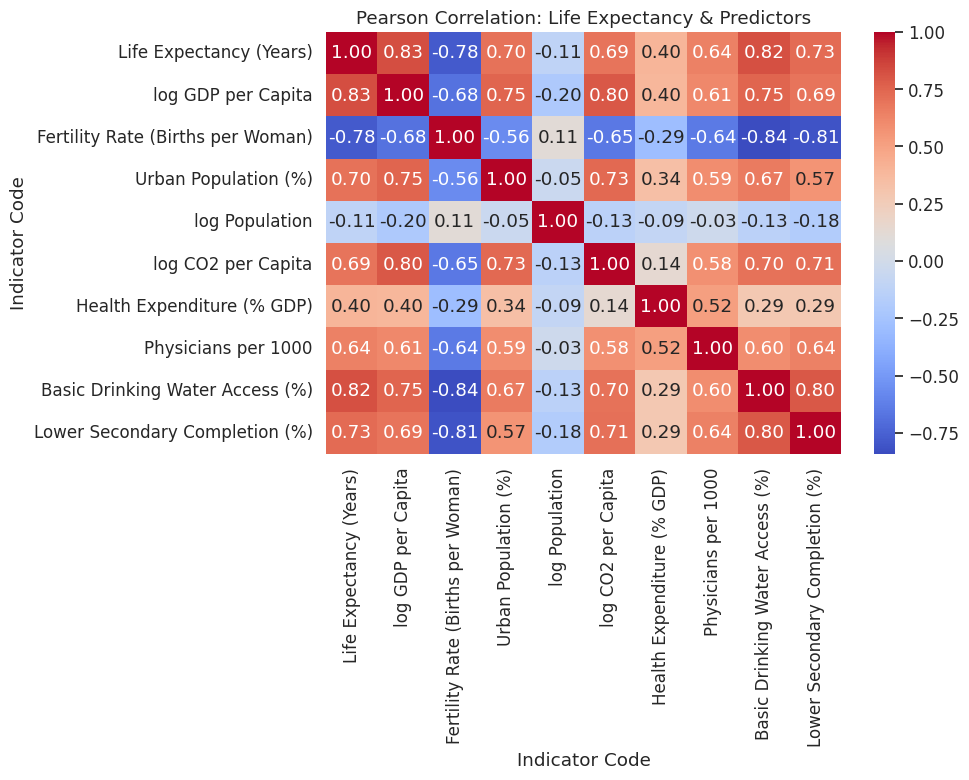

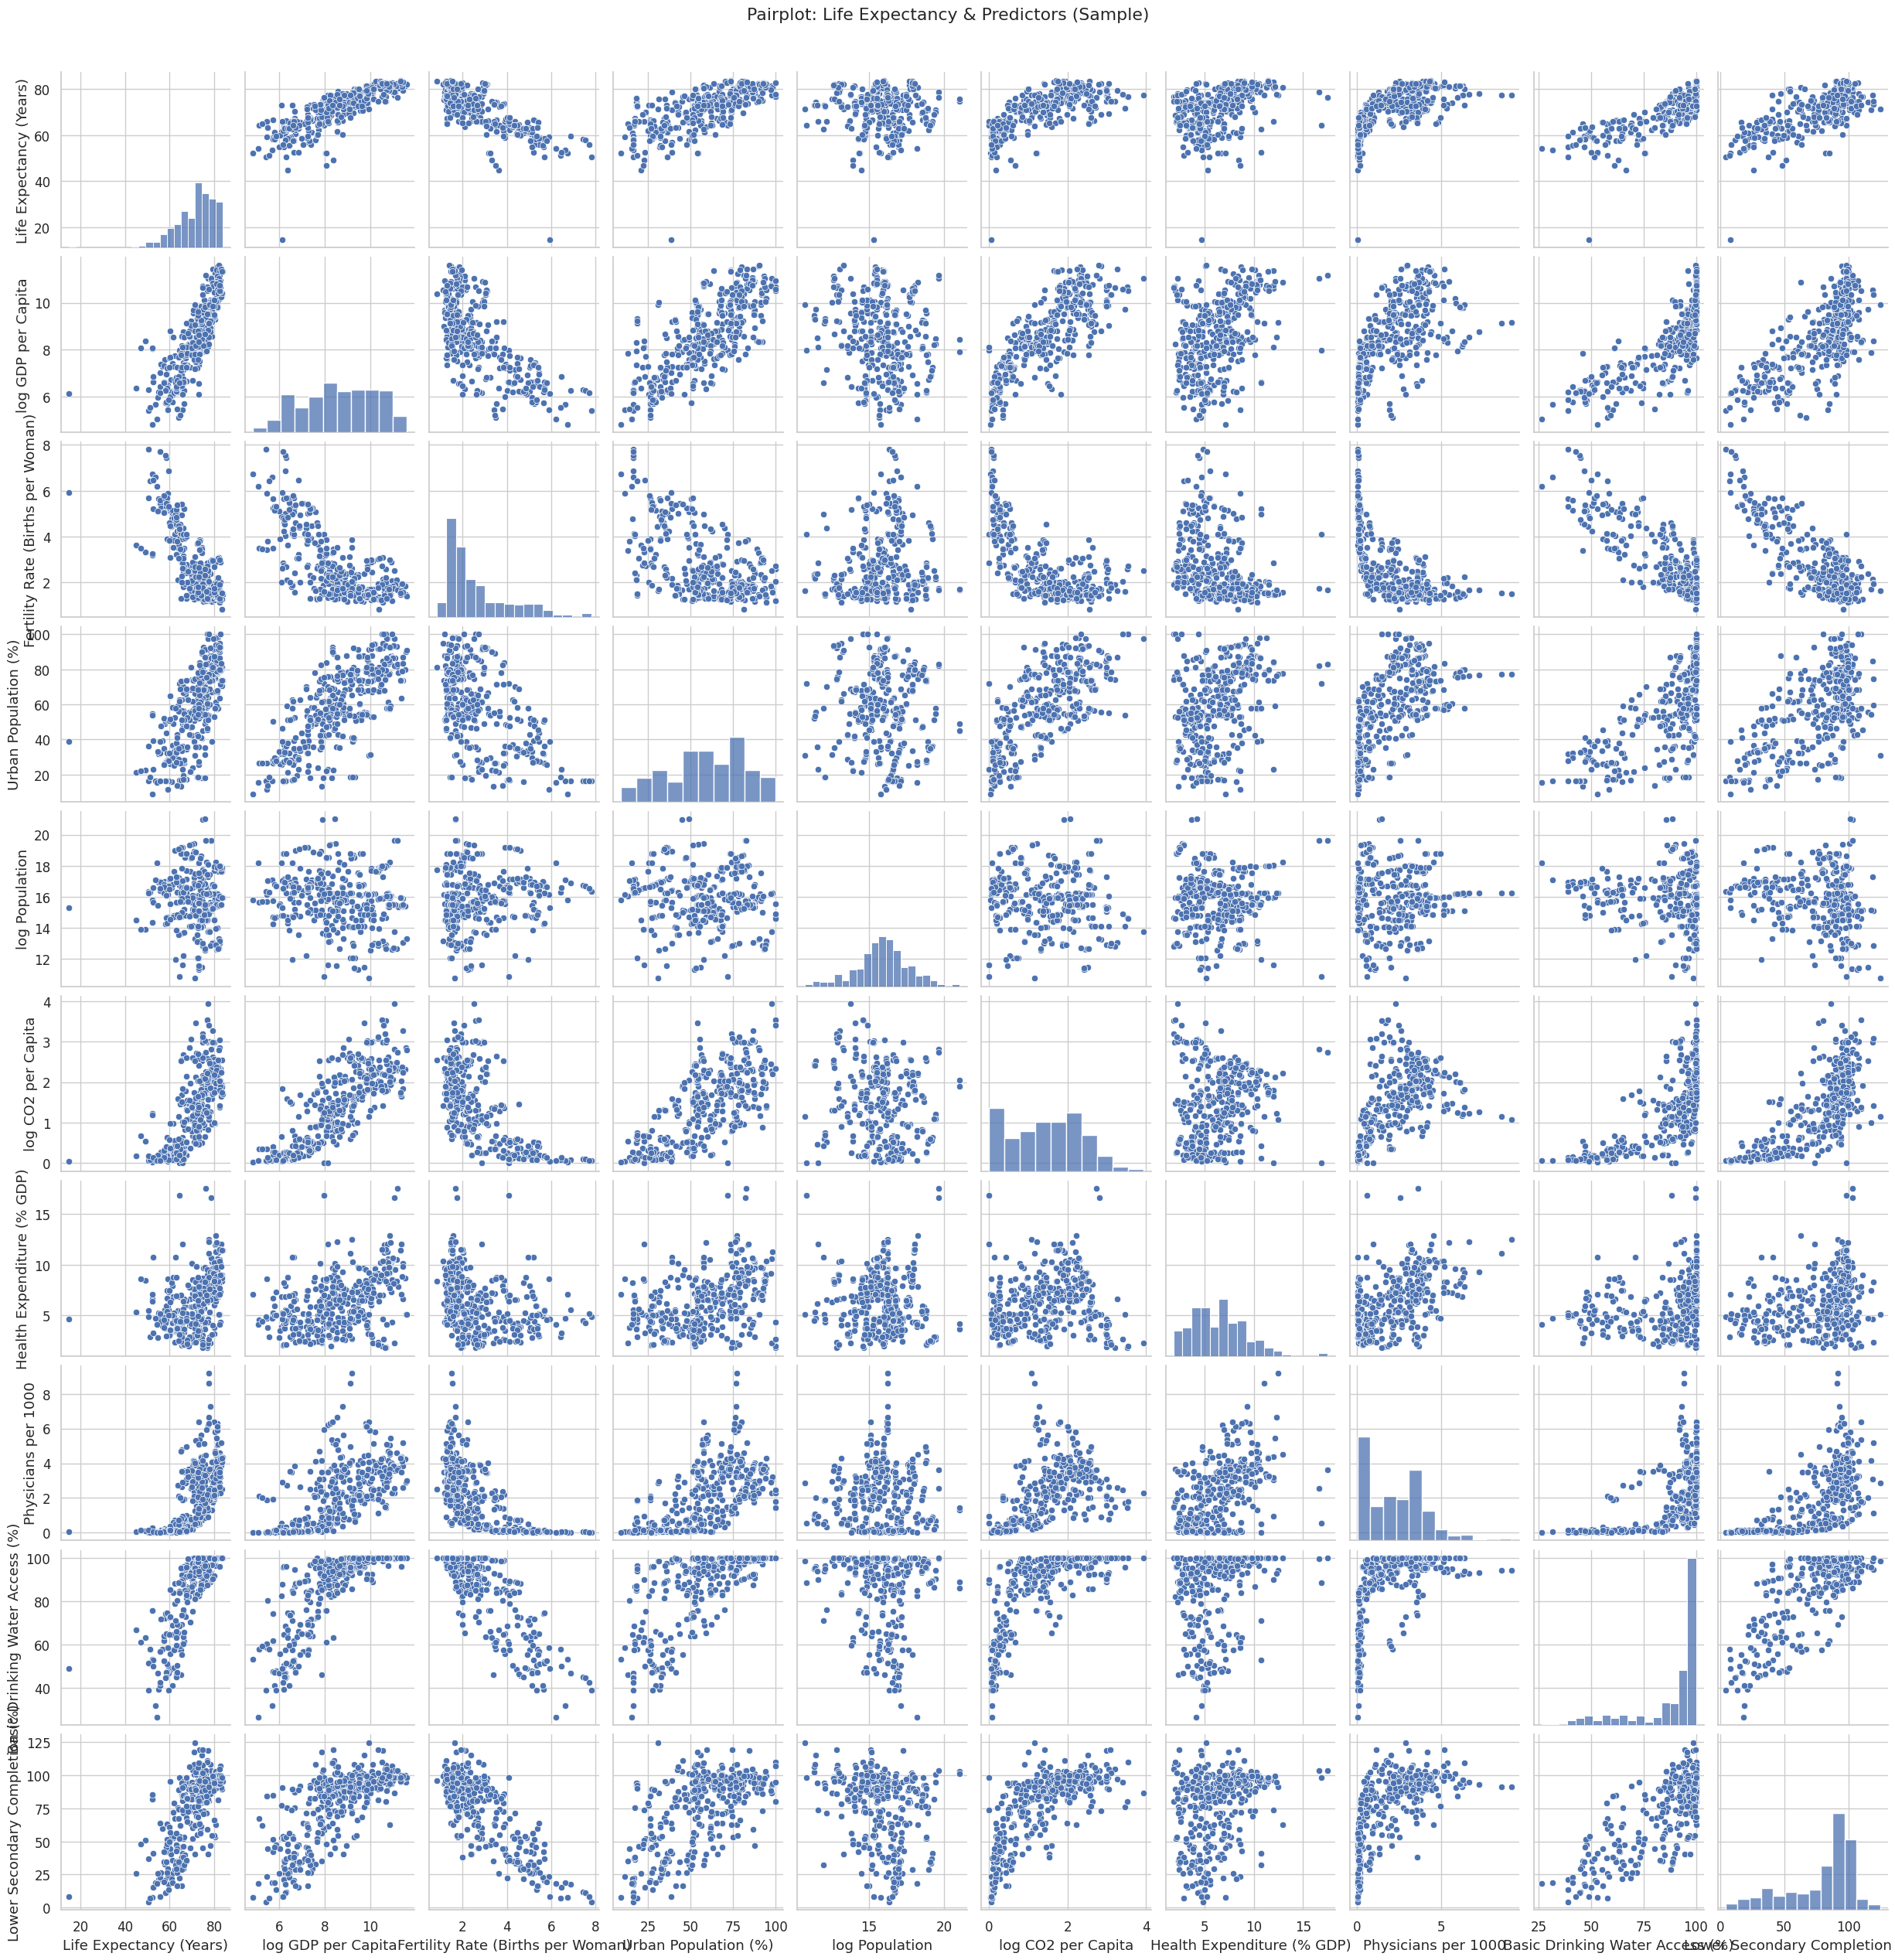

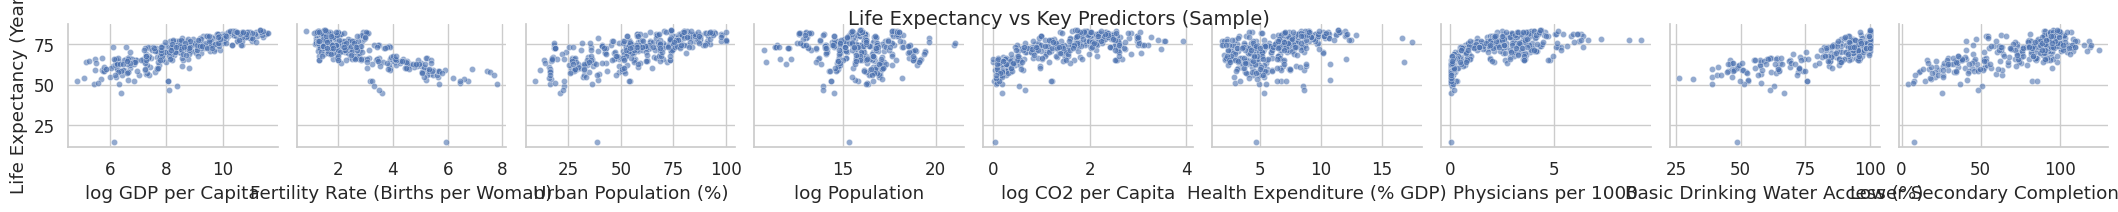

In [ ]:
# EDA

plt.figure(figsize=(8, 5))
sns.histplot(df_model[target_col], kde=True, bins=30)
plt.title("Distribution of Life Expectancy (Years)")
plt.xlabel("Life Expectancy (Years)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Correlation matrix for target + predictors
corr_cols = [target_col] + feature_candidates
corr = df_model[corr_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation: Life Expectancy & Predictors")
plt.tight_layout()
plt.show()

# Sample pairplot
sample_df = df_model[corr_cols].sample(
    n=min(400, len(df_model)), random_state=42
)
sns.pairplot(sample_df)
plt.suptitle("Pairplot: Life Expectancy & Predictors (Sample)", y=1.02)
plt.show()

# Smaller, target-centered pairplot
sns.pairplot(
    sample_df,
    y_vars=[target_col],
    x_vars=feature_candidates,
    height=2.0,
    aspect=1.2,
    plot_kws={"alpha": 0.6, "s": 20}
)

plt.suptitle(
    "Life Expectancy vs Key Predictors (Sample)",
    y=1.02,
    fontsize=14
)
plt.show()



In [ ]:
# Train/Validation Split (Regression)


X = df_model[feature_candidates]
y = df_model[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train shape:", X_train_scaled.shape, "Val shape:", X_val_scaled.shape)


Train shape: (1309, 9) Val shape: (328, 9)


In [ ]:
# Helper: Regression Metrics


def print_regression_metrics(name, model, X_tr, y_tr, X_te, y_te):
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    mae_tr = mean_absolute_error(y_tr, y_tr_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    r2_tr  = r2_score(y_tr, y_tr_pred)

    mae_te = mean_absolute_error(y_te, y_te_pred)
    rmse_te = np.sqrt(mean_squared_error(y_te, y_te_pred))
    r2_te  = r2_score(y_te, y_te_pred)

    print(f"\n=== {name} ===")
    print(f"Train  MAE:  {mae_tr:.3f}, RMSE: {rmse_tr:.3f}, R^2: {r2_tr:.3f}")
    print(f"Val    MAE:  {mae_te:.3f}, RMSE: {rmse_te:.3f}, R^2: {r2_te:.3f}")

# SETUP FOR COLLECTING RESULTS INTO A TABLE

results = []

def collect_results(model_name, model, X_tr, y_tr, X_te, y_te):
    ytr_pred = model.predict(X_tr)
    yte_pred = model.predict(X_te)

    mae_tr = mean_absolute_error(y_tr, ytr_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, ytr_pred))
    r2_tr  = r2_score(y_tr, ytr_pred)

    mae_te = mean_absolute_error(y_te, yte_pred)
    rmse_te = np.sqrt(mean_squared_error(y_te, yte_pred))
    r2_te  = r2_score(y_te, yte_pred)

    results.append([
        model_name, mae_tr, rmse_tr, r2_tr, mae_te, rmse_te, r2_te
    ])

    print_regression_metrics(model_name, model, X_tr, y_tr, X_te, y_te)




In [ ]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

collect_results(
    "OLS Baseline",
    ols,
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

lasso_cv = LassoCV(
    alphas=None,
    cv=5,
    max_iter=5000,
    random_state=42
)
lasso_cv.fit(X_train_scaled, y_train)

print("Best alpha (LASSO):", lasso_cv.alpha_)

collect_results(
    "LASSO (CV)",
    lasso_cv,
    X_train_scaled, y_train,
    X_val_scaled, y_val
)
elastic_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    cv=5,
    max_iter=5000,
    random_state=42
)
elastic_cv.fit(X_train_scaled, y_train)

print("Best alpha (Elastic Net):", elastic_cv.alpha_)
print("Best l1_ratio (Elastic Net):", elastic_cv.l1_ratio_)

collect_results(
    "Elastic Net (CV)",
    elastic_cv,
    X_train_scaled, y_train,
    X_val_scaled, y_val
)
alphas = np.logspace(-3, 3, 7)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print("Best alpha (Ridge):", ridge_cv.alpha_)

collect_results(
    "RidgeCV",
    ridge_cv,
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf_reg.fit(X_train, y_train)

collect_results(
    "RandomForest",
    rf_reg,
    X_train, y_train,
    X_val, y_val
)
svr_params = {
    "C": [0.1, 1, 5, 10, 20],
    "gamma": ["scale", 0.1, 0.01],
    "kernel": ["rbf"]
}

svr_cv = GridSearchCV(SVR(), svr_params, cv=5, scoring="neg_mean_squared_error")
svr_cv.fit(X_train, y_train)

print("Best SVR params:", svr_cv.best_params_)

best_svr = svr_cv.best_estimator_

collect_results(
    "SVR (RBF)",
    best_svr,
    X_train, y_train,
    X_val, y_val
)
results_df = pd.DataFrame(
    results,
    columns=["Model", "Train MAE", "Train RMSE", "Train R2",
             "Val MAE", "Val RMSE", "Val R2"]
)

results_df





=== OLS Baseline ===
Train  MAE:  2.346, RMSE: 3.432, R^2: 0.810
Val    MAE:  2.506, RMSE: 3.509, R^2: 0.809
Best alpha (LASSO): 0.006556031877991904

=== LASSO (CV) ===
Train  MAE:  2.345, RMSE: 3.433, R^2: 0.810
Val    MAE:  2.505, RMSE: 3.508, R^2: 0.809
Best alpha (Elastic Net): 0.009365759825702721
Best l1_ratio (Elastic Net): 0.7

=== Elastic Net (CV) ===
Train  MAE:  2.343, RMSE: 3.433, R^2: 0.810
Val    MAE:  2.504, RMSE: 3.507, R^2: 0.809
Best alpha (Ridge): 10.0

=== RidgeCV ===
Train  MAE:  2.343, RMSE: 3.433, R^2: 0.810
Val    MAE:  2.503, RMSE: 3.507, R^2: 0.809

=== RandomForest ===
Train  MAE:  0.377, RMSE: 0.752, R^2: 0.991
Val    MAE:  1.100, RMSE: 1.798, R^2: 0.950
Best SVR params: {'C': 20, 'gamma': 0.01, 'kernel': 'rbf'}

=== SVR (RBF) ===
Train  MAE:  0.532, RMSE: 1.482, R^2: 0.965
Val    MAE:  1.293, RMSE: 2.384, R^2: 0.912


,Model,Train MAE,Train RMSE,Train R2,Val MAE,Val RMSE,Val R2
0,OLS Baseline,2.345700,3.432401,0.810157,2.506049,3.509165,0.808507
1,LASSO (CV),2.344608,3.432514,0.810144,2.504720,3.507548,0.808684
2,Elastic Net (CV),2.343456,3.432708,0.810123,2.503513,3.506624,0.808785
3,RidgeCV,2.342654,3.432920,0.810100,2.502833,3.506628,0.808784
4,RandomForest,0.377306,0.751928,0.990889,1.099531,1.797926,0.949732
5,SVR (RBF),0.531956,1.482317,0.964594,1.293460,2.383583,0.911650


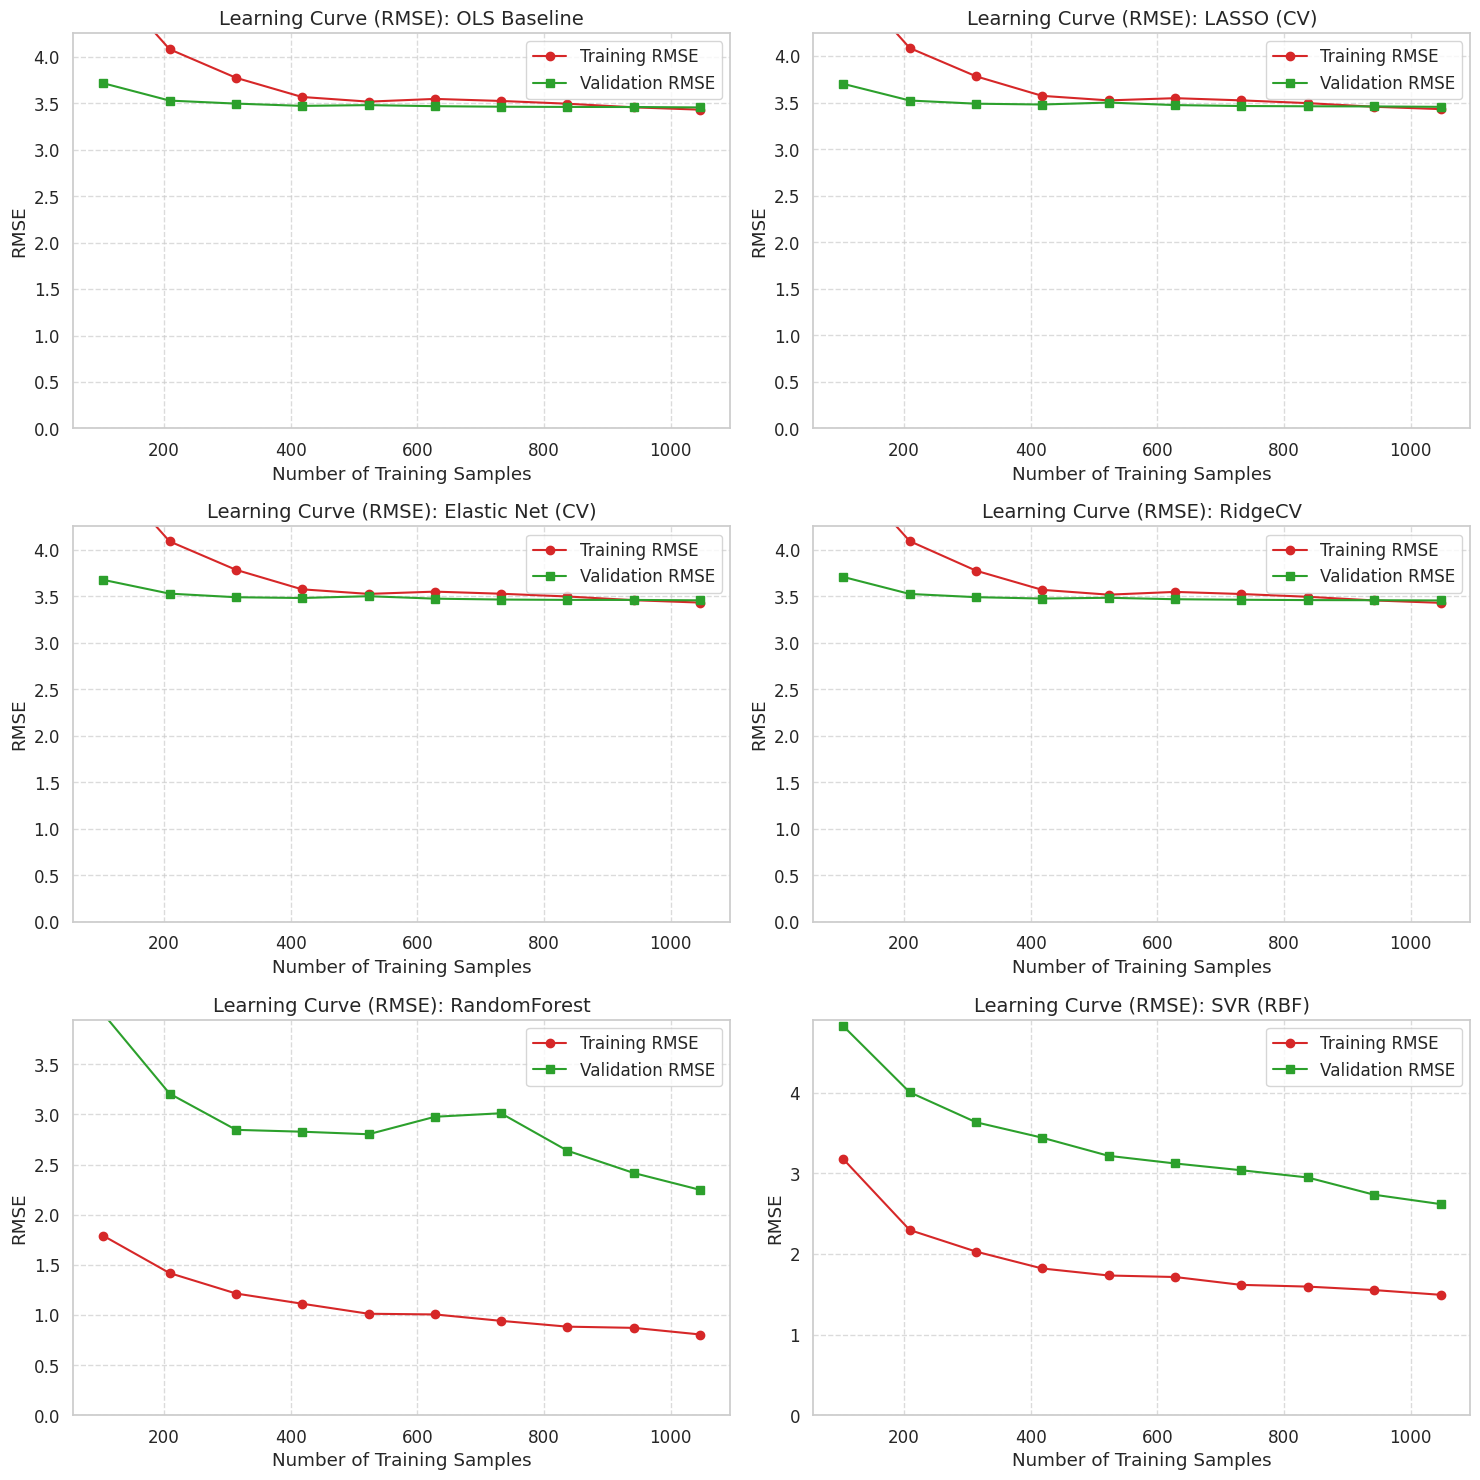

In [ ]:
def plot_learning_curves_rmse(models, y):
    n_models = len(models)
    cols = 2
    rows = (n_models + 1) // 2

    plt.figure(figsize=(15, rows * 5))

    for i, (name, model, X_data) in enumerate(models):
        train_sizes, train_scores, val_scores = learning_curve(
            model, X_data, y, cv=5, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='neg_mean_squared_error' # Sklearn returns negative MSE
        )

        # Convert to RMSE: sqrt(-1 * negative_mse)
        train_rmse = np.sqrt(-train_scores.mean(axis=1))
        val_rmse = np.sqrt(-val_scores.mean(axis=1))

        plt.subplot(rows, cols, i + 1)
        plt.plot(train_sizes, train_rmse, 'o-', color="tab:red", label="Training RMSE")
        plt.plot(train_sizes, val_rmse, 's-', color="tab:green", label="Validation RMSE")

        plt.title(f"Learning Curve (RMSE): {name}", fontsize=14)
        plt.xlabel("Number of Training Samples")
        plt.ylabel("RMSE")

        # Adjust y-limit to focus on the area where curves converge
        y_limit = np.percentile(val_rmse, 90) * 1.2
        plt.ylim(0, y_limit)

        plt.legend(loc="upper right")
        plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Plotting the learning curves
models_to_plot = [
    ("OLS Baseline", ols, X_train_scaled),
    ("LASSO (CV)", lasso_cv, X_train_scaled),
    ("Elastic Net (CV)", elastic_cv, X_train_scaled),
    ("RidgeCV", ridge_cv, X_train_scaled),
    ("RandomForest", rf_reg, X_train),
    ("SVR (RBF)", best_svr, X_train)
]

plot_learning_curves_rmse(models_to_plot, y_train)

In [ ]:
# Visualize training performance
train_metrics = results_df.melt(
    id_vars="Model",
    value_vars=["Train MAE", "Train RMSE", "Train R2"],
    var_name="Metric",
    value_name="Value"
)

fig = px.bar(
    train_metrics,
    y="Model",
    x="Value",
    color="Metric",
    barmode="group",
    text="Value",
    orientation="h",
    color_discrete_map={
        "Train MAE": "darkgreen",
        "Train RMSE": "seagreen",
        "Train R2": "lightgreen"
    },
    title="Training Performance by Model"
)

fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.update_layout(
    xaxis_title="Metric Value",
    yaxis_title="Model",
    margin=dict(l=150, r=50, t=80, b=50)
)

fig.show()


In [ ]:
# Visualize validation performance

val_metrics = results_df.melt(
    id_vars="Model",
    value_vars=["Val MAE", "Val RMSE", "Val R2"],
    var_name="Metric",
    value_name="Value"
)

fig = px.bar(
    val_metrics,
    y="Model",
    x="Value",
    color="Metric",
    barmode="group",
    text="Value",
    orientation="h",
    color_discrete_map={
        "Val MAE": "darkblue",
        "Val RMSE": "steelblue",
        "Val R2": "lightblue"
    },
    title="Validation Performance by Model"
)

fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.update_layout(
    xaxis_title="Metric Value",
    yaxis_title="Model",
    margin=dict(l=150, r=50, t=80, b=50)
)

fig.show()



=== SGDRegressor ===
Train  MAE:  2.345, RMSE: 3.443, R^2: 0.809
Val    MAE:  2.549, RMSE: 3.538, R^2: 0.805


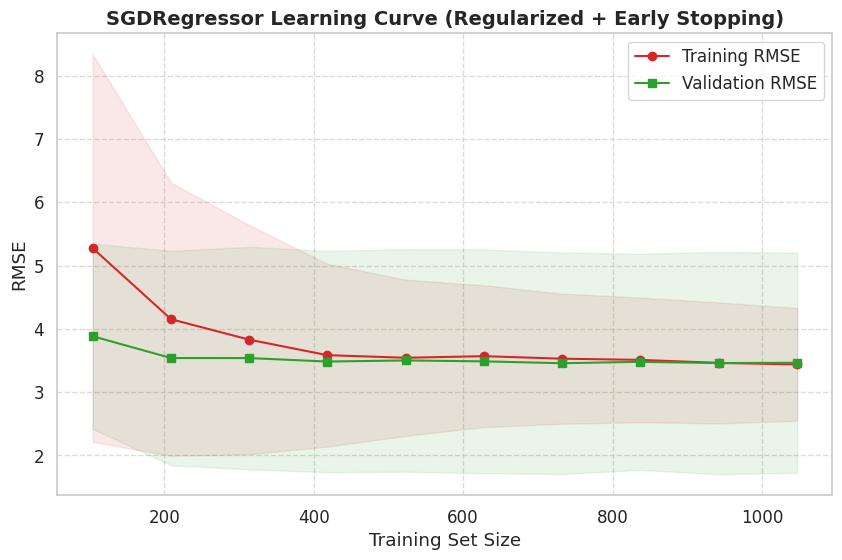

In [ ]:
# Initialize the SGDRegressor with parameters
sgd_reg = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=0.001,
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=5,
    validation_fraction=0.2,
    learning_rate="invscaling",
    eta0=0.01,
    random_state=42
)

# Fit and Print Metrics
sgd_reg.fit(X_train_scaled, y_train)

print_regression_metrics(
    "SGDRegressor",
    sgd_reg,
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

# Calculate Learning Curve Data
train_sizes, train_scores, val_scores = learning_curve(
    sgd_reg, X_train_scaled, y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error'
)

# Process scores (Convert Negative MSE to positive RMSE)
train_rmse_mean = np.sqrt(-train_scores.mean(axis=1))
train_rmse_std = np.sqrt(train_scores.std(axis=1))
val_rmse_mean = np.sqrt(-val_scores.mean(axis=1))
val_rmse_std = np.sqrt(val_scores.std(axis=1))

# Visualize the Results
plt.figure(figsize=(10, 6))

# Plot Training RMSE
plt.plot(train_sizes, train_rmse_mean, 'o-', color="#d62728", label="Training RMSE")
plt.fill_between(train_sizes, train_rmse_mean - train_rmse_std,
                 train_rmse_mean + train_rmse_std, alpha=0.1, color="#d62728")

# Plot Validation RMSE
plt.plot(train_sizes, val_rmse_mean, 's-', color="#2ca02c", label="Validation RMSE")
plt.fill_between(train_sizes, val_rmse_mean - val_rmse_std,
                 val_rmse_mean + val_rmse_std, alpha=0.1, color="#2ca02c")

plt.title("SGDRegressor Learning Curve (Regularized + Early Stopping)", fontsize=14, fontweight='bold')
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

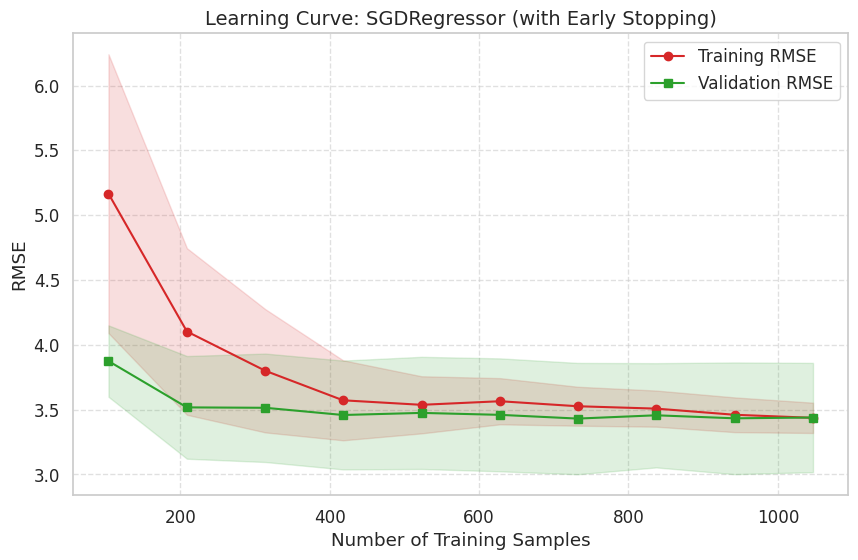

In [ ]:
def plot_sgd_learning_curve(model, X, y):
    # Calculate the learning curve data
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error'
    )

    # Convert negative MSE to RMSE
    train_rmse = np.sqrt(-train_scores)
    val_rmse = np.sqrt(-val_scores)

    # Calculate mean and standard deviation
    train_mean = np.mean(train_rmse, axis=1)
    train_std = np.std(train_rmse, axis=1)
    val_mean = np.mean(val_rmse, axis=1)
    val_std = np.std(val_rmse, axis=1)

    plt.figure(figsize=(10, 6))

    # Plot training RMSE with shading
    plt.plot(train_sizes, train_mean, 'o-', color="tab:red", label="Training RMSE")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color="tab:red")

    # Plot validation RMSE with shading
    plt.plot(train_sizes, val_mean, 's-', color="tab:green", label="Validation RMSE")
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color="tab:green")

    plt.title("Learning Curve: SGDRegressor (with Early Stopping)", fontsize=14)
    plt.xlabel("Number of Training Samples")
    plt.ylabel("RMSE")
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_sgd_learning_curve(sgd_reg, X_train_scaled, y_train)


######################################################################
#  HEALTH EFFICIENCY CLUSTERING USING: Latest Year
######################################################################


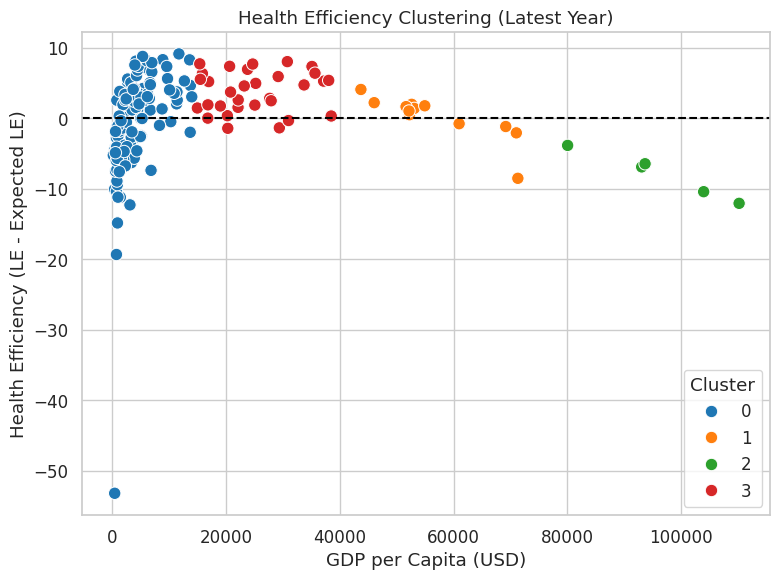


=== Latest Year: Top 10 Over-Performers (High LE relative to GDP) ===


Indicator Code,Country Name,Life Expectancy (Years),GDP per Capita (US$),Efficiency
56,Maldives,79.707000,11740.272403,9.149026
84,Albania,77.824000,5370.777500,8.792143
54,Lebanon,78.208000,8905.880055,8.329140
149,Costa Rica,79.316000,13625.900849,8.306233
58,Bosnia and Herzegovina,77.394000,6122.375345,8.182062
50,Jordan,76.865000,4170.114400,8.120819
96,Spain,83.178049,30799.477594,8.053530
74,Thailand,77.331000,6985.643939,7.912224
150,Chile,79.176000,15405.616577,7.739817
122,Portugal,81.378049,24711.451006,7.712208



=== Latest Year: Top 10 Under-Performers (Low LE relative to GDP) ===


Indicator Code,Country Name,Life Expectancy (Years),GDP per Capita (US$),Efficiency
19,"Congo, Dem. Rep.",57.795000,431.191528,-10.053343
21,Guinea,57.581000,765.146999,-10.347358
101,Ireland,82.253659,103961.976351,-10.400438
142,Lesotho,56.812000,1030.125796,-11.179846
12,Zambia,56.896000,1451.106160,-11.196712
34,Luxembourg,82.095122,110193.213797,-12.051966
7,Angola,56.225000,3136.645470,-12.271564
90,Chad,53.136000,946.358500,-14.835776
1,Nigeria,48.618000,763.388745,-19.309937
6,Central African Republic,14.665000,456.471674,-53.189400



######################################################################
#  HEALTH EFFICIENCY CLUSTERING USING: Mean Over Years
######################################################################


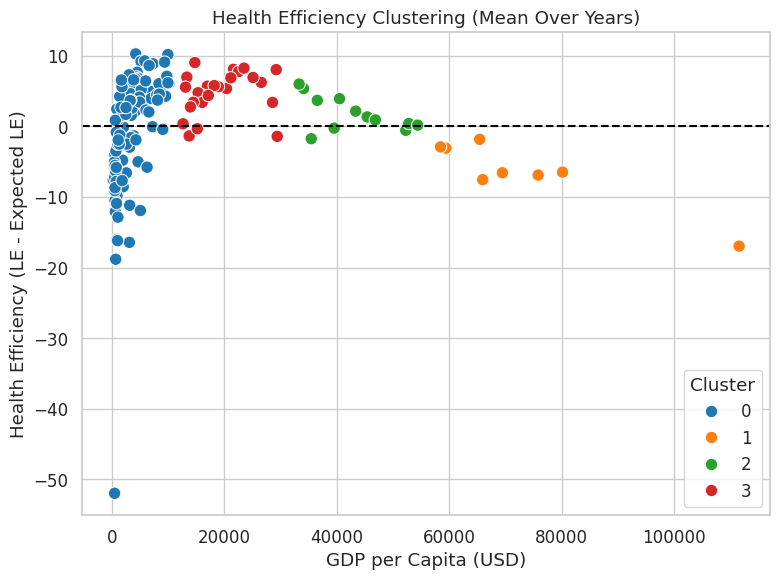


=== Mean Over Years: Top 10 Over-Performers (High LE relative to GDP) ===


Indicator Code,Country Name,Life Expectancy (Years),GDP per Capita (US$),Efficiency
1,Albania,77.982667,4217.116439,10.267463
36,Costa Rica,79.511389,9934.264158,10.174114
39,Cuba,77.443857,5820.065971,9.273864
19,Bosnia and Herzegovina,77.196300,5152.965918,9.215577
90,Maldives,78.276429,9355.966507,9.103228
30,Chile,79.743250,14732.389024,9.044649
82,Lebanon,77.457417,7288.551015,8.870785
147,Thailand,77.006500,6604.439892,8.613964
119,Portugal,81.426829,23473.839604,8.248099
58,Greece,80.736748,21601.555344,8.089224



=== Mean Over Years: Top 10 Under-Performers (Low LE relative to GDP) ===


Indicator Code,Country Name,Life Expectancy (Years),GDP per Capita (US$),Efficiency
3,Angola,56.225000,3136.645470,-11.183651
20,Botswana,56.027000,5054.550166,-11.925800
61,Guinea,54.599500,582.844873,-12.084586
164,Zambia,53.954400,1044.503599,-12.860668
29,Chad,50.756800,878.039940,-16.011039
83,Lesotho,50.604000,975.881777,-16.191599
49,Eswatini,50.960250,3080.564546,-16.432490
86,Luxembourg,81.211308,111583.213307,-16.965855
107,Nigeria,47.880500,655.353522,-18.824158
28,Central African Republic,14.665000,456.471674,-51.983231



######################################################################
#  HEALTH EFFICIENCY CLUSTERING USING: Last Non-Null
######################################################################


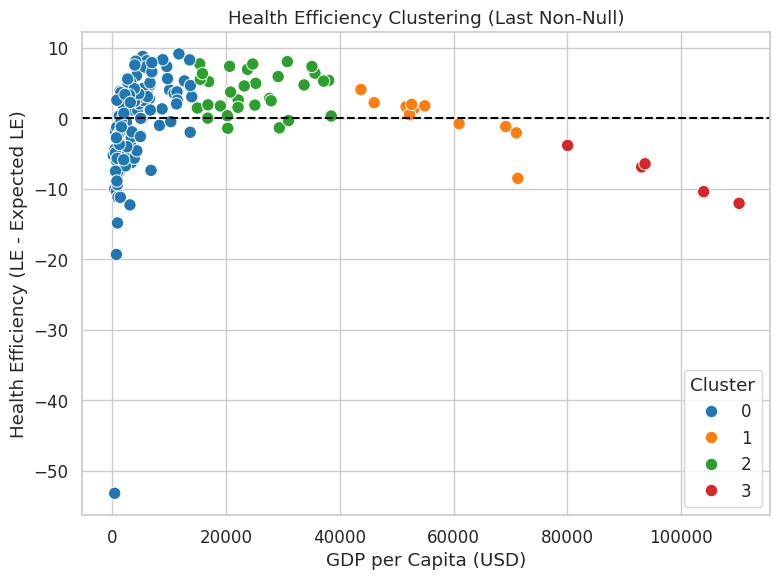


=== Last Non-Null: Top 10 Over-Performers (High LE relative to GDP) ===


Indicator Code,Country Name,Life Expectancy (Years),GDP per Capita (US$),Efficiency
90,Maldives,79.707000,11740.272403,9.149026
1,Albania,77.824000,5370.777500,8.792143
82,Lebanon,78.208000,8905.880055,8.329140
36,Costa Rica,79.316000,13625.900849,8.306233
19,Bosnia and Herzegovina,77.394000,6122.375345,8.182062
74,Jordan,76.865000,4170.114400,8.120819
135,Spain,83.178049,30799.477594,8.053530
147,Thailand,77.331000,6985.643939,7.912224
30,Chile,79.176000,15405.616577,7.739817
119,Portugal,81.378049,24711.451006,7.712208



=== Last Non-Null: Top 10 Under-Performers (Low LE relative to GDP) ===


Indicator Code,Country Name,Life Expectancy (Years),GDP per Capita (US$),Efficiency
34,"Congo, Dem. Rep.",57.795000,431.191528,-10.053343
61,Guinea,57.581000,765.146999,-10.347358
70,Ireland,82.253659,103961.976351,-10.400438
83,Lesotho,56.812000,1030.125796,-11.179846
164,Zambia,56.896000,1451.106160,-11.196712
86,Luxembourg,82.095122,110193.213797,-12.051966
3,Angola,56.225000,3136.645470,-12.271564
29,Chad,53.136000,946.358500,-14.835776
107,Nigeria,48.618000,763.388745,-19.309937
28,Central African Republic,14.665000,456.471674,-53.189400


In [ ]:
#   HEALTH EFFICIENCY CLUSTERING WITH 3 AGG STRATEGIES

cols_needed = [
    "Country Name",
    "Year",
    "Life Expectancy (Years)",
    "GDP per Capita (US$)"
]

df_base = df_model[cols_needed].dropna(subset=["Life Expectancy (Years)", "GDP per Capita (US$)"])

# Helper: aggregation strategies (one row per country)


def latest_year(df):
    """Use the most recent year per country."""
    return (
        df.sort_values("Year")
          .groupby("Country Name")
          .tail(1)[["Country Name", "Life Expectancy (Years)", "GDP per Capita (US$)"]]
          .reset_index(drop=True)
    )

def mean_over_years(df):
    """Use the mean value over all years per country."""
    return (
        df.groupby("Country Name")[["Life Expectancy (Years)", "GDP per Capita (US$)"]]
          .mean()
          .reset_index()
    )

def last_non_null(df):
    """Use the last non-null value observed per country."""
    def last_valid(s):
        s = s.dropna()
        return s.iloc[-1] if not s.empty else None

    return (
        df.groupby("Country Name")[["Life Expectancy (Years)", "GDP per Capita (US$)"]]
          .agg(last_valid)
          .dropna()
          .reset_index()
    )

agg_strategies = {
    "Latest Year": latest_year,
    "Mean Over Years": mean_over_years,
    "Last Non-Null": last_non_null
}

# Helper to run efficiency clustering for a given df_country

def run_efficiency_clustering(df_country, label):
    df_cluster_raw = df_country.copy()

    # Fit regression: Life Expectancy ~ GDP
    reg_ce = LinearRegression()
    reg_ce.fit(
        df_cluster_raw[["GDP per Capita (US$)"]],
        df_cluster_raw["Life Expectancy (Years)"]
    )

    # Compute efficiency residuals
    df_cluster_raw["LE_pred"] = reg_ce.predict(df_cluster_raw[["GDP per Capita (US$)"]])
    df_cluster_raw["Efficiency"] = (
        df_cluster_raw["Life Expectancy (Years)"] - df_cluster_raw["LE_pred"]
    )

    # KMeans on GDP + Efficiency
    X_ce = df_cluster_raw[["GDP per Capita (US$)", "Efficiency"]]
    kmeans_ce = KMeans(n_clusters=4, random_state=42, n_init="auto")
    df_cluster_raw["Cluster"] = kmeans_ce.fit_predict(X_ce)

    # Plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_cluster_raw,
        x="GDP per Capita (US$)",
        y="Efficiency",
        hue="Cluster",
        palette="tab10",
        s=80
    )
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("GDP per Capita (USD)")
    plt.ylabel("Health Efficiency (LE - Expected LE)")
    plt.title(f"Health Efficiency Clustering ({label})")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

    # Top / bottom performers
    df_sorted = df_cluster_raw.sort_values("Efficiency", ascending=False)

    print(f"\n=== {label}: Top 10 Over-Performers (High LE relative to GDP) ===")
    display(df_sorted[["Country Name", "Life Expectancy (Years)", "GDP per Capita (US$)", "Efficiency"]].head(10))

    print(f"\n=== {label}: Top 10 Under-Performers (Low LE relative to GDP) ===")
    display(df_sorted[["Country Name", "Life Expectancy (Years)", "GDP per Capita (US$)", "Efficiency"]].tail(10))

    return df_cluster_raw

# Run all three strategies

cluster_results = {}

for label, func in agg_strategies.items():
    print("\n" + "#"*70)
    print(f"#  HEALTH EFFICIENCY CLUSTERING USING: {label}")
    print("#"*70)
    df_country = func(df_base)
    cluster_results[label] = run_efficiency_clustering(df_country, label)

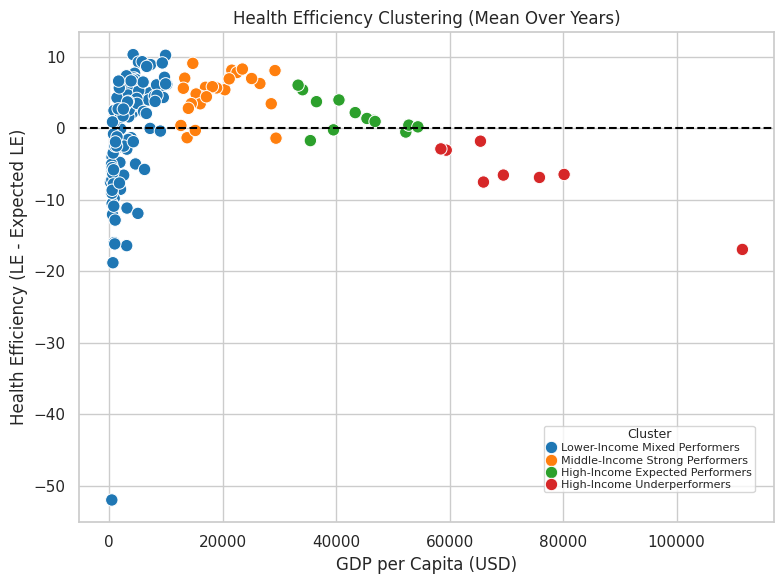


=== Mean Over Years: Top 10 Over-Performers (Higher LE than expected) ===


Indicator Code,Country Name,Life Expectancy (Years),GDP per Capita (US$),Efficiency,ClusterName
1,Albania,77.982667,4217.116439,10.267463,Lower-Income Mixed Performers
36,Costa Rica,79.511389,9934.264158,10.174114,Lower-Income Mixed Performers
39,Cuba,77.443857,5820.065971,9.273864,Lower-Income Mixed Performers
19,Bosnia and Herzegovina,77.196300,5152.965918,9.215577,Lower-Income Mixed Performers
90,Maldives,78.276429,9355.966507,9.103228,Lower-Income Mixed Performers
30,Chile,79.743250,14732.389024,9.044649,Middle-Income Strong Performers
82,Lebanon,77.457417,7288.551015,8.870785,Lower-Income Mixed Performers
147,Thailand,77.006500,6604.439892,8.613964,Lower-Income Mixed Performers
119,Portugal,81.426829,23473.839604,8.248099,Middle-Income Strong Performers
58,Greece,80.736748,21601.555344,8.089224,Middle-Income Strong Performers



=== Mean Over Years: Top 10 Under-Performers (Lower LE than expected) ===


Indicator Code,Country Name,Life Expectancy (Years),GDP per Capita (US$),Efficiency,ClusterName
3,Angola,56.225000,3136.645470,-11.183651,Lower-Income Mixed Performers
20,Botswana,56.027000,5054.550166,-11.925800,Lower-Income Mixed Performers
61,Guinea,54.599500,582.844873,-12.084586,Lower-Income Mixed Performers
164,Zambia,53.954400,1044.503599,-12.860668,Lower-Income Mixed Performers
29,Chad,50.756800,878.039940,-16.011039,Lower-Income Mixed Performers
83,Lesotho,50.604000,975.881777,-16.191599,Lower-Income Mixed Performers
49,Eswatini,50.960250,3080.564546,-16.432490,Lower-Income Mixed Performers
86,Luxembourg,81.211308,111583.213307,-16.965855,High-Income Underperformers
107,Nigeria,47.880500,655.353522,-18.824158,Lower-Income Mixed Performers
28,Central African Republic,14.665000,456.471674,-51.983231,Lower-Income Mixed Performers


In [ ]:

#   HEALTH EFFICIENCY CLUSTERING (Mean Over Years Only)
#   - KMeans with 4 clusters
#   - Names hard-coded based on mean clustering pattern


sns.set(style="whitegrid")

# Base data (df_model must already exist)

cols_needed = [
    "Country Name",
    "Year",
    "Life Expectancy (Years)",
    "GDP per Capita (US$)"
]

df_base = df_model[cols_needed].dropna(
    subset=["Life Expectancy (Years)", "GDP per Capita (US$)"]
)


# Aggregate to mean over years (one row per country)


def mean_over_years(df):
    """Use the mean value over all years per country."""
    return (
        df.groupby("Country Name")[["Life Expectancy (Years)", "GDP per Capita (US$)"]]
          .mean()
          .reset_index()
    )

df_mean = mean_over_years(df_base)


# Regression + efficiency residuals


reg_ce = LinearRegression()
reg_ce.fit(
    df_mean[["GDP per Capita (US$)"]],
    df_mean["Life Expectancy (Years)"]
)

df_mean["LE_pred"] = reg_ce.predict(df_mean[["GDP per Capita (US$)"]])
df_mean["Efficiency"] = df_mean["Life Expectancy (Years)"] - df_mean["LE_pred"]


# KMeans clustering on (GDP, Efficiency)


X_ce = df_mean[["GDP per Capita (US$)", "Efficiency"]]

kmeans_ce = KMeans(n_clusters=4, random_state=42, n_init="auto")
df_mean["Cluster"] = kmeans_ce.fit_predict(X_ce)


#  HARD-CODED NAMES based on this mean clustering

CLUSTER_NAME_MEAN = {
    0: "Lower-Income Mixed Performers",   # mostly low GDP, wide efficiency spread
    1: "High-Income Underperformers",     # very high GDP, negative efficiency
    2: "High-Income Expected Performers", # high GDP, around expected LE
    3: "Middle-Income Strong Performers"  # middle GDP, positive efficiency
}

df_mean["ClusterName"] = df_mean["Cluster"].map(CLUSTER_NAME_MEAN)


# Plot (Mean Over Years) with cluster names


fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=df_mean,
    x="GDP per Capita (US$)",
    y="Efficiency",
    hue="ClusterName",
    palette="tab10",
    s=80,
    ax=ax
)

ax.axhline(0, color="black", linestyle="--")
ax.set_xlabel("GDP per Capita (USD)")
ax.set_ylabel("Health Efficiency (LE - Expected LE)")
ax.set_title("Health Efficiency Clustering (Mean Over Years)")

# Legend
ax.legend(
    title="Cluster",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.05),
    borderpad=0.2,
    labelspacing=0.2,
    handlelength=1.0,
    handletextpad=0.4,
    prop={"size": 8},
    title_fontsize=9
)

fig.tight_layout()
plt.show()


# Top / bottom performers tables


df_sorted = df_mean.sort_values("Efficiency", ascending=False)

print("\n=== Mean Over Years: Top 10 Over-Performers (Higher LE than expected) ===")
display(df_sorted[[
    "Country Name",
    "Life Expectancy (Years)",
    "GDP per Capita (US$)",
    "Efficiency",
    "ClusterName"
]].head(10))

print("\n=== Mean Over Years: Top 10 Under-Performers (Lower LE than expected) ===")
display(df_sorted[[
    "Country Name",
    "Life Expectancy (Years)",
    "GDP per Capita (US$)",
    "Efficiency",
    "ClusterName"
]].tail(10))


In [ ]:
fig = px.choropleth(
    df_mean,
    locations="Country Name",
    locationmode="country names",
    color="Efficiency",
    color_continuous_scale="RdYlGn",
    range_color=[-20, 20],
    hover_name="Country Name",
    hover_data={
        "GDP per Capita (US$)": True,
        "Life Expectancy (Years)": True,
        "Efficiency": True
    },
    title="Global Health Efficiency (LE - Expected LE)"
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Efficiency (years)")
)
fig.show()



In [ ]:
# Sort and take the top 10
top_over = df_mean.sort_values("Efficiency", ascending=False).head(10)

fig = px.bar(
    top_over,
    x="Efficiency",
    y="Country Name",
    orientation="h",
    color="Efficiency",
    color_continuous_scale="Greens",
    title="<b>Top 10 Over-Performers<br>(Countries Living Longer Than Expected)</b>",
    labels={"Efficiency": "Efficiency (years)", "Country Name": ""}
)

fig.update_layout(
    yaxis=dict(autorange="reversed"),  # largest at top
    title_x=0.5,
    margin=dict(l=120, r=30, t=70, b=40)
)

fig.show()


In [ ]:
# Sort and take the bottom 10
top_under = df_mean.sort_values("Efficiency", ascending=True).head(10)

fig = px.bar(
    top_under,
    x="Efficiency",
    y="Country Name",
    orientation="h",
    color="Efficiency",
    color_continuous_scale="Reds",
    title="<b>Top 10 Under-Performers<br>(Countries Living Shorter Than Expected)</b>",
    labels={"Efficiency": "Efficiency (years)", "Country Name": ""}
)

fig.update_layout(
    yaxis=dict(autorange="reversed"),
    title_x=0.5,
    margin=dict(l=120, r=30, t=70, b=40)
)

fig.show()


In [ ]:

!pip install kaleido


# Take top 10 in each direction
over = df_mean.sort_values("Efficiency", ascending=False).head(10)
under = df_mean.sort_values("Efficiency", ascending=True).head(10)

combo = pd.concat([over, under], axis=0)
combo["Group"] = ["Over-performer"] * 10 + ["Under-performer"] * 10

fig = px.bar(
    combo,
    x="Efficiency",
    y="Country Name",
    orientation="h",
    color="Group",
    color_discrete_map={
        "Over-performer": "green",
        "Under-performer": "crimson"
    },
    title="<b>Top Over- and Under-Performing Countries</b>",
    labels={"Efficiency": "Health Efficiency (LE - Expected LE)", "Country Name": ""}
)

fig.update_layout(
    yaxis=dict(autorange="reversed"),
    title_x=0.5,
    margin=dict(l=140, r=50, t=70, b=40)
)

fig.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.9 MB/s eta 0:00:00
